---
title: "Deelvraag 2"
subtitle: "Analyse van Feature Importance in een Random Forest-model"
title-block-style: plain
author: "Jalisa Shaline van der Zeeuw"
date: "January 2026"
format:
  pdf:
    geometry: margin=2.5cm
    include-code: false
number-sections: false
execute:
  echo: false
  warning: false
  message: false
---

# Analyse van Feature Importance in een Random Forest-mode

In dit notebook wordt één geneesmiddel geselecteerd om de interpretatie van het Random Forest-model op pathway-niveau te demonstreren. 

Zoals eerder beschreven is de keuze voor `PF-05212384` gebaseerd op een combinatie van datacompleetheid, behoud van samplegrootte en de beschikbaarheid van bestaande biologische kennis, wat het mogelijk maakt om modeluitkomsten beter te interpreteren.

Het doel van deze analyse is niet om conclusies te trekken over dit specifieke geneesmiddel, maar om te laten zien hoe een machine learning-model biologische pathway-informatie gebruikt bij het voorspellen van therapierespons.

**Deelvraag2**: Hoe kan feature importance uit een Random Forest-model worden bepaald en gebruikt om inzicht te krijgen in de bijdrage van pathway-gebaseerde mutatie- en methylatiefeatures aan de voorspelling van therapie respons?

De beschreven pipeline is toepasbaar op verschillende geneesmiddelen. Indien er tijd genoeg is kan als uitbreiding dezelfde analyse worden uitgevoerd voor een tweede geneesmiddel, zoals *Bezosertib*, om te verkennen of het Random Forest-model daarbij andere pathways als belangrijk identificeert.

## Data-invoer en selectie


Voor deze analyse worden twee datasets gebruikt:  
- X: een pathway-level featurematrix, voorbereid in notebook *dv1_dataprep.ipynb* (`pathway_features.pkl`).  
- y: drug-responsdata, voorbereid in notebook *dataprep_response.ipynb* (`response_matrix.pkl`)

Om datalek te voorkomen worden features `(X)` en respons `(y)` gescheiden ingeladen. Ter controle wordt eerst de shape van beide datasets weergegeven. Vervolgens kan er een geneesmiddel worden geselecteerd uit de responsmatrix dat in de verdere analyse wordt gebruikt.

Tot slot worden de featurematrix en de geselecteerde responsvector op elkaar afgestemd, waarbij uitsluitend cellijnen worden meegenomen waarvoor zowel pathway-features als responsdata beschikbaar zijn. Na afstemming vormen `X_aligned` en `y_aligned` de definitieve dataset die wordt gebruikt voor modeltraining en verdere analyse.

In [2]:
import os
import pandas as pd

# inladen
X = pd.read_pickle("../data/processed/pathway_features.pkl") # featurematrix
y = pd.read_pickle("../data/processed/response_matrix.pkl") # drug-responsematrix

# controle shape
print("Output:")
print("Featurematrix (X):", X.shape)
print("Responsmatrix (y):", y.shape)

# selecteer één geneesmiddel 
drug_name = "PF-05212384" 

# selecteer responsvector
y_drug = y[drug_name]

print("Aantal cellijnen met responsdata (vóór afstemming met features):",
    y_drug.shape[0])

# bepaal overlap in cellijnen
common_ids = X.index.intersection(y_drug.index)

# stem X en y op elkaar af
X_aligned = X.loc[common_ids]
y_aligned = y_drug.loc[common_ids]
# opmerking: dit betekend dat we niet meer verder gaan met X en y maar met X_aligned en y_aligned !!!

# controle 
print("Aantal cellijnen na afstemming:", X_aligned.shape[0])


Output:
Featurematrix (X): (82, 100)
Responsmatrix (y): (93, 1450)
Aantal cellijnen met responsdata (vóór afstemming met features): 93
Aantal cellijnen na afstemming: 82


In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# extra controle
assert X_aligned.index.equals(y_aligned.index), "Indices van X en y komen niet overeen"
print("Inputdata gecontroleerd: klaar voor modeltraining.")

# trainen 
rf_model1 = RandomForestRegressor(
    n_estimators=500, # aantal bomen
    random_state=17, 
    n_jobs=-1
)

rf_model1.fit(X_aligned, y_aligned)

print("Random Forest-model succesvol getraind.")

Inputdata gecontroleerd: klaar voor modeltraining.
Random Forest-model succesvol getraind.


## Trainen van het model

[korte introductie van het model, met verwijzing naar een apart bewijsstuk/bijlage voor verdieping, wat voor model, waarom dit model geschikt is voor deze data, wat er mee wordt gedaan (interpretatie)
]
In deze stap wordt een Random Forest-regressiemodel getraind op de afgestemde dataset (X_aligned en y_aligned). Deze analyse is gericht op het verkrijgen van inzicht in welke pathway-gebaseerde features door het model worden gebruikt bij het voorspellen van therapierespons, en niet op het evalueren van de voorspellende prestaties.

Het model wordt getraind op de volledige beschikbare dataset, zodat alle informatie kan worden benut voor de analyse van feature importance. Om deze reden wordt in deze fase bewust geen train-test-splitsing toegepast.

De Random Forest die in dit notebook wordt getraind, fungeert puur als interpretatiemdodel. In het vervolg bij deelvraag 3 wordt een afzonderlijke Random Forest-model opgebouwd, waarin met behulp van een train-rest-splitsing de generaliseerbaarheid en prestaties van het model worden geëvalueerd.

Er is gekozen voor een relatief hoog aantal bomen om stabiliteit van de feature importance te vergroten.


## Feature Importance


Feature importance binnen een Random Forest geeft aan in welke mate individuele featuers bijdragen aan het maken van voorsellingen door het model. De feature importance weerspiegelt hoe vaak en hoe effectied pathway-gebaseerde kenmerken worden gebruikt om de therapierespons van longkankercellijnen te voorspellen.

Een hogere feature importance betekent dat een pathway relatief meer bijdraagt aan het verkleinen van de voorspelfout van het model. Deze maat geeft daarmee inzicht in welke biologische pathways het model als het meest informatief beschouwd. 

Om deze informatie overzichtelijk te presenteren, worden de feature importances gevisualiseerd in figuren. Zowel de meest invloedrijke individuele pathways als de relatieve bijdrage van mutatie- en methylatiepathways worden afzonderlijk weergeven. 


#### Individuele Pathway Importance

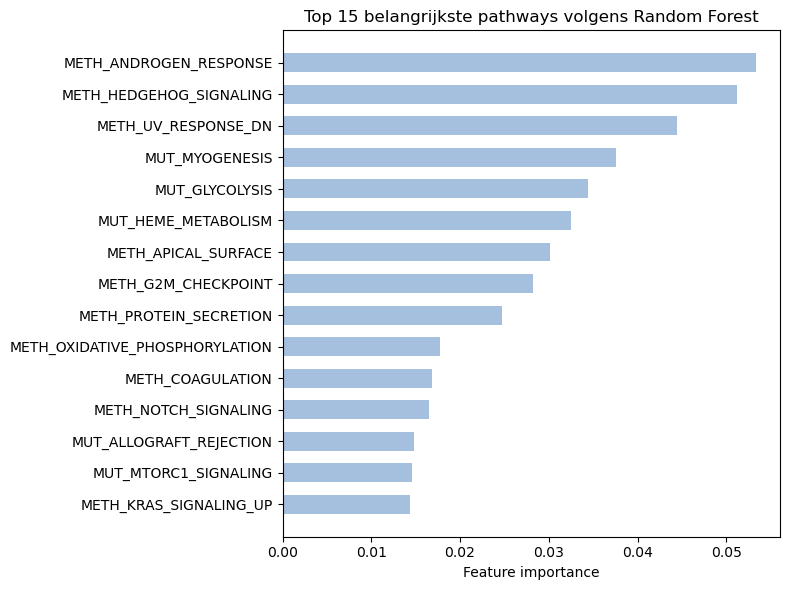

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# haal de feature importance uit getrainde model
importances = rf_model1.feature_importances_

# maak dataframe aan met pathway-namen
feature_importance_df = pd.DataFrame({
    "Pathway": X_aligned.columns,
    "Importance": importances})

# sorteer van hoog naar laag
feature_importance_df = feature_importance_df.sort_values(by = "Importance", ascending = False)

# toon top 15 belangrijkste pathways
top_n = 15
top_features = feature_importance_df.head(top_n)


# visualisatie
plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Pathway"],
    top_features["Importance"],
    height=0.6, # dikte van balken
    alpha=0.8, # intensiteit balken
    color="#8FAFD6"
)
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title(f"Top {top_n} belangrijkste pathways volgens Random Forest")
plt.tight_layout()
plt.show() 

***Figuur 1**. Top 15 pathways met de hoogste feature importance volgens het Random Forest-model.*

Figuur 1 laat zien dat meerdere van de hoogst gerangschikte pathways gebaseerd zijn op DNA-methylatiegegevens. Dit wijst erop dat epigenetische kenmerken een belangrijke rol spelen in de voorspelling van therapierespons.

De hoogste feature importances worden toegekend aan de volgende methylatie gebaseerde pathways:  
- Androgen_response (hormonale signaaltransductie)  
- Hedgehog_signaling (ontwikkelingsgerelateerde signaling)  
- UV_response_dn (cellulaire stressresponsen)  

Deze pathways vormen daarmee de meest informatieve kenmerken binnen dit model.

Ook zijn er enkele mutatie-gebaseerde pathways aanwezig in de top van de ranglijst, wat aangeeft dat zowel genetische als epigenetische informatie bijdraagt aan de voorspelling van therapierespons. De relatieve verdeling tussen deze twee wordt in de volgende stap geanalyseerd.


#### Mutatie versus Methylatie

[zelfe maar groepen op type. verdeling en relatieve bijdrage]

Om de feature importance verder samen te vatten, worden de pathway-features gegroepeerd op basis van hun herkomst: mutatie of DNA-methylatie. Door de verdeling van de feature importances binnen beide groepen te vergelijken, wordt inzicht verkregen in de relatieve bijdrage van genetische en epigenetische informatie aan het model.

In [5]:
# maak kopie
fi_grouped = feature_importance_df.copy()

fi_grouped["Type"] = fi_grouped["Pathway"].apply(lambda x: "Mutatie" if x.startswith("MUT_") else "Methylatie")

# controle
print("Output controle van de groepering:")
fi_grouped["Type"].value_counts()

Output controle van de groepering:


Type
Methylatie    50
Mutatie       50
Name: count, dtype: int64

## Biologische interpretatie van de belangrijkste pathways


Pathways met de hoogste feature importance kunnen nader worden bekeken vanuit biologisch perspectief. Het doel is hierbij niet om te concluderen dat specifieke pathways de therapierespons veroorzaken, maar om te onderzoeken of welke kanker-gerelateerde biologische processen door het model als belangrijk worden beschouwd.

Deze analyse dient ter ondersteuning van de interpretatie van het model en plaatst de uitkomsten van de pathway-analyse in een biologische context.

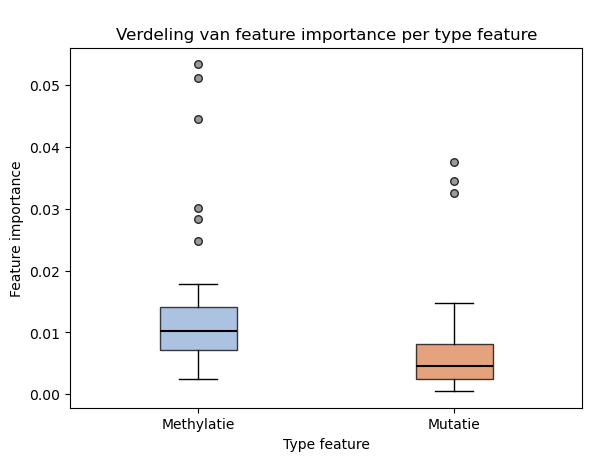

In [6]:
# visualisatie
      
# maak boxplot
fi_grouped.boxplot(
    column="Importance",
    by="Type",
    grid=False,
    patch_artist=True,
    widths=0.3,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(
        marker='o',
        markersize=5.5,
        markerfacecolor='grey',
        markeredgecolor='black',
        alpha=0.8
    )
)

# kleuren
for box, color in zip(plt.gca().patches, ["#8FAFD6", "#DD8452"]):
    box.set_facecolor(color)
    box.set_alpha(0.75)

# as en layout
plt.suptitle(" ") # geen titel
plt.title("Verdeling van feature importance per type feature")
plt.ylabel("Feature importance")
plt.xlabel("Type feature")

plt.gca().set_xlim(0.5, 2.5)

plt.tight_layout
plt.show()

***Figuur 2.** Verdeling van feature importance per type feature. Methylatie-features vertonen een gemiddelde importance van 0.013 (SD = 0.009; min = 0.002; max = 0.053), terwijl mutatie-features een gemiddelde importance hebben van 0.007 (SD = 0.007; min = 0.001; max = 0.038).*
    
De boxplot in figuur 2 laten zien dat methylatie-pathways over het algemeen hogere feature importance-waarden hebben dan mutatie-pathways. Zowel de mediaan als het grootste deel van de verdeling ligt bij methylatie hoger, terwijl mutatie-pathways voornamelijk lagere importance-waarden vertonen.

Voor beide groepen is de verdeling scheef, met een beperkt aantal pathways die duidelijk hogere importance-waarden hebben dan de rest. Deze hoogst gerangschikte pathways worden in de boxplot als uitbijters weergegeven en laten zien dat de bijdrage van individuele pathways sterk varieert binnen het Random Forest-model.

**Beantwoording van de deelvraag**

In dit notebook is onderzocht hoe feature importance in een Random Forest-model kan worden bepaald en gebruikt om inzicht te krijgen in de bijdrage van pathway-gebaseerde mutatie- en methylatiefeatures aan de voorspelling van therapierespons in longkankercellijnen.

Er is een Random Forest-model getraind op de in het vorige notebook (dv1_dataprep.ipynb) geconstrueerde pathway-features, waarna feature importance is berekend om te achterhalen welke pathways het meest bijdragen aan de modelvoorspellingen. De analyse is uitgevoerd op zowel individuele pathway-niveau als op het niveau van type moleculaire informatie.

Deze aanpak laat zien dat de feature importance kan worden ingezet om inzicht te verkrijgen in welke biologische processen door het model worden benadrukt bij het voorspellen van therapierespons.